In [2]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import seaborn as sns
import librosa
from pathlib import Path
import random
import shutil

Создание файла csv с предсказанными и истинными метриками для nnces

In [ ]:
input_file = 'nnces_age_predictions.txt'
output_file = 'nnces_predictions_processed.csv'

data = []
with open(input_file, 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            parts = line.rsplit(' ', 1)
            if len(parts) == 2:
                file_path = parts[0]
                predicted_age = float(parts[1])
                data.append((file_path, predicted_age))

df = pd.DataFrame(data, columns=['file_path', 'predicted_age'])

# Извлекаем информацию из пути
def extract_info_from_path(path):
    parts = path.split('/')
    
    true_age = None
    if parts and 'Y' in parts[0]:
        age_str = parts[0].replace('Y', '')
        try:
            true_age = int(age_str)
        except:
            pass
    
    speaker_id = None
    for part in parts:
        if re.match(r'^[MF]\d+$', part):  # M11, F12 и т.д.
            speaker_id = part
            break
    
    return true_age, speaker_id

df[['true_age', 'speaker_id']] = df['file_path'].apply(
    lambda x: pd.Series(extract_info_from_path(x))
)

df = df[['file_path', 'speaker_id', 'true_age', 'predicted_age']]

# Сохраняем в CSV
df.to_csv(output_file, index=False, encoding='utf-8')

print(f"Файл сохранен: {output_file}")

Файл сохранен: nnces_predictions_processed.csv


Вычисление ошибок

In [ ]:
df_preds = pd.read_csv('./nnces_predictions.csv')

In [6]:
df_preds.shape

(999, 4)

In [5]:
df_preds.head()

,file_path,speaker_id,true_age,predicted_age
0,10Y/Boys_10/M11/M11_01/M11_01_02.wav,M11,10,19.59
1,10Y/Boys_10/M11/M11_01/M11_01_06.wav,M11,10,23.04
2,10Y/Boys_10/M11/M11_03/M11_03_07.wav,M11,10,21.33
3,10Y/Boys_10/M11/M11_04/M11_04_06.wav,M11,10,24.98
4,10Y/Boys_10/M11/M11_05/M11_05_07.wav,M11,10,24.16


In [6]:
age_counts = df_preds.groupby('true_age')['speaker_id'].count()
print(age_counts)

true_age
8     212
9     187
10    204
11    204
12    192
Name: speaker_id, dtype: int64


In [8]:
df_preds['error'] = df_preds['predicted_age'] - df_preds['true_age']  
df_preds['abs_error'] = abs(df_preds['error'])                  
df_preds['squared_error'] = df_preds['error'] ** 2              

# Метрики
MAE = abs(df_preds['predicted_age'] - df_preds['true_age']).mean()
MSE = ((df_preds['predicted_age'] - df_preds['true_age'])**2).mean()
RMSE = np.sqrt(MSE)
STD_ERROR = (df_preds['predicted_age'] - df_preds['true_age']).std()

# Дополнительные метрики в пределах
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100

print("Метрики оценки")

print(f"\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print(f"\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:   {within_10_years:.1f}%")

print(f"\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")

Метрики оценки

Основные метрики:
MAE  (Mean Absolute Error):     13.578 лет
RMSE (Root Mean Squared Error): 14.811 лет
Std of Error (разброс ошибок):  5.933 лет

Процент ошибок в пределах:
  ≤ 1 год:   0.6%
  ≤ 3 года:  1.7%
  ≤ 5 лет:   4.1%
  ≤ 10 лет:   27.1%

Статистика абсолютных ошибок:
  Мин ошибка:  0.270 лет
  Медиана:     13.260 лет
  Макс ошибка: 41.230 лет


Разница возрастных распределений

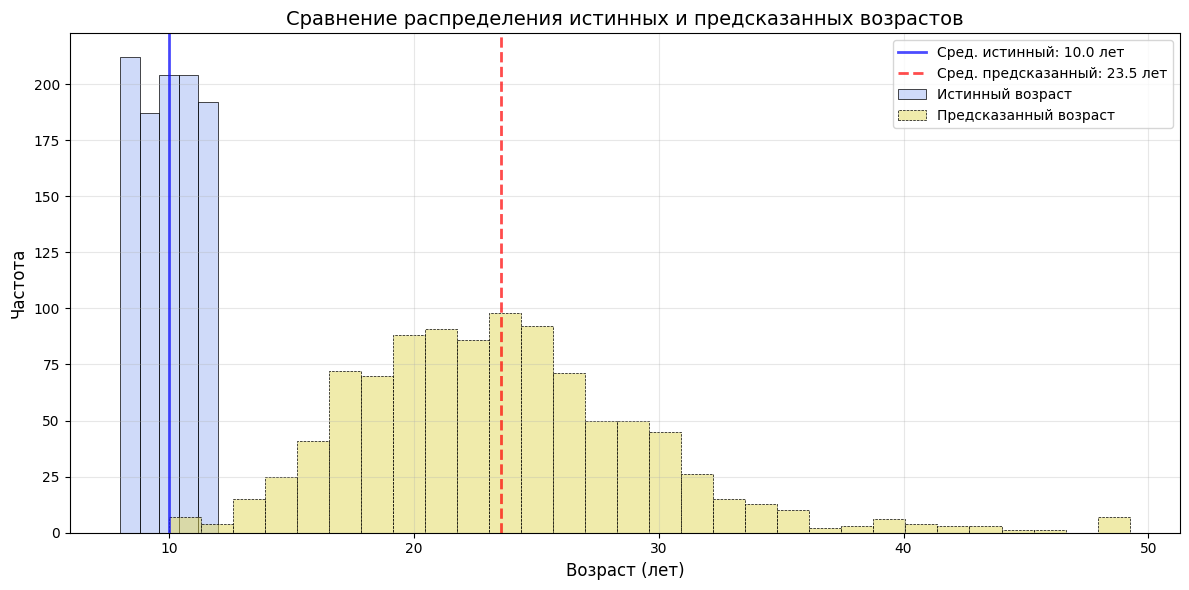

In [9]:
# Стилизованный вариант
plt.figure(figsize=(12, 6))

# Используем разные стили для наглядности
sns.histplot(data=df_preds, x='true_age', bins=5, 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='predicted_age', bins=30, 
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

# Добавляем вертикальные линии средних
plt.axvline(df_preds['true_age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["true_age"].mean():.1f} лет')
plt.axvline(df_preds['predicted_age'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["predicted_age"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()